In [1]:
from ultralytics import YOLO

In [2]:
model = YOLO("yolo11n-pose.pt")

In [4]:
import cv2
from ultralytics import YOLO

# -----------------------
# LOAD MODEL
# -----------------------

model = YOLO("yolo11n-pose.pt")

# -----------------------
# VIDEO PATH
# -----------------------

video_path = "D:/pose estimation badminton/videos/smash/smash_01.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video")
    exit()

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Run pose detection
    results = model(frame)

    # Plot skeleton on frame
    annotated_frame = results[0].plot()

    # Show frame
    cv2.imshow("YOLO Pose", annotated_frame)

    # Press Q to exit
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 3 persons, 74.6ms
Speed: 2.4ms preprocess, 74.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 80.8ms
Speed: 2.5ms preprocess, 80.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 107.1ms
Speed: 2.5ms preprocess, 107.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 100.1ms
Speed: 2.7ms preprocess, 100.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 74.5ms
Speed: 2.3ms preprocess, 74.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 69.2ms
Speed: 2.5ms preprocess, 69.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 80.6ms
Speed: 2.0ms preprocess, 80.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 66.9ms
Speed: 2.2ms preprocess, 66.9ms inference, 1.3ms postprocess per image at sha

In [2]:
import os

video_path = "D:/pose estimation badminton/videos/smash/smash_01.mp4"

print("File exists:", os.path.exists(video_path))

File exists: True


In [3]:
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO("yolo11n-pose.pt")

video_path = "D:/pose estimation badminton/videos/smash/smash_10.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Could not open video")
    exit()

prev_center = None
prev_area = None

while True:

    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape

    results = model(frame, verbose=False)[0]

    if results.boxes is None or results.keypoints is None:
        cv2.imshow("Pose Tracking", frame)
        if cv2.waitKey(30) == ord("q"):
            break
        continue

    boxes = results.boxes.xyxy.cpu().numpy()
    keypoints = results.keypoints.xy.cpu().numpy()

    best_index = None
    best_score = 1e12

    # FIRST FRAME → choose largest bottom player
    if prev_center is None:

        best_area = -1

        for i, box in enumerate(boxes):

            x1, y1, x2, y2 = box
            area = (x2-x1)*(y2-y1)

            center_y = (y1+y2)/2

            if center_y > h/2 and area > best_area:
                best_area = area
                best_index = i

    # TRACKING MODE
    else:

        for i, box in enumerate(boxes):

            x1, y1, x2, y2 = box

            center = np.array([(x1+x2)/2, (y1+y2)/2])
            area = (x2-x1)*(y2-y1)

            dist = np.linalg.norm(center - prev_center)

            size_diff = abs(area - prev_area)

            score = dist + 0.001 * size_diff

            if score < best_score:
                best_score = score
                best_index = i

    if best_index is not None:

        x1, y1, x2, y2 = boxes[best_index]

        center = np.array([(x1+x2)/2, (y1+y2)/2])
        area = (x2-x1)*(y2-y1)

        prev_center = center
        prev_area = area

        pts = keypoints[best_index]

        for x, y in pts:
            cv2.circle(frame, (int(x), int(y)), 5, (0,255,0), -1)

        cv2.rectangle(frame,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      (0,255,0), 2)

        cv2.putText(frame,
                    "Tracked Player",
                    (int(x1), int(y1)-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0,255,0),
                    2)

    cv2.imshow("Pose Tracking", frame)

    if cv2.waitKey(30) == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
#extract_pose

import os
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm

VIDEO_ROOT = "D:/pose estimation badminton/videos"
OUTPUT_ROOT = "D:/pose estimation badminton/pose_data"

model = YOLO("yolo11n-pose.pt")

os.makedirs(OUTPUT_ROOT, exist_ok=True)

for class_name in os.listdir(VIDEO_ROOT):

    class_folder = os.path.join(VIDEO_ROOT, class_name)

    if not os.path.isdir(class_folder):
        continue

    output_class_folder = os.path.join(OUTPUT_ROOT, class_name)
    os.makedirs(output_class_folder, exist_ok=True)

    videos = [v for v in os.listdir(class_folder) if v.endswith(".mp4")]

    for video_name in tqdm(videos, desc=class_name):

        video_path = os.path.join(class_folder, video_name)

        cap = cv2.VideoCapture(video_path)

        sequence = []

        prev_center = None
        prev_area = None

        while True:

            ret, frame = cap.read()
            if not ret:
                break

            h, w, _ = frame.shape

            results = model(frame, verbose=False)[0]

            if results.boxes is None or results.keypoints is None:
                continue

            boxes = results.boxes.xyxy.cpu().numpy()
            keypoints = results.keypoints.xy.cpu().numpy()

            best_index = None

            # FIRST FRAME SELECTION
            if prev_center is None:

                best_area = -1

                for i, box in enumerate(boxes):

                    x1, y1, x2, y2 = box
                    area = (x2-x1)*(y2-y1)
                    center_y = (y1+y2)/2

                    if center_y > h/2 and area > best_area:
                        best_area = area
                        best_index = i

            # TEMPORAL TRACKING
            else:

                best_score = 1e12

                for i, box in enumerate(boxes):

                    x1, y1, x2, y2 = box

                    center = np.array([(x1+x2)/2, (y1+y2)/2])
                    area = (x2-x1)*(y2-y1)

                    dist = np.linalg.norm(center - prev_center)
                    size_diff = abs(area - prev_area)

                    score = dist + 0.001 * size_diff

                    if score < best_score:
                        best_score = score
                        best_index = i

            if best_index is None:
                continue

            x1, y1, x2, y2 = boxes[best_index]

            center = np.array([(x1+x2)/2, (y1+y2)/2])
            area = (x2-x1)*(y2-y1)

            prev_center = center
            prev_area = area

            pts = keypoints[best_index]

            frame_features = pts.flatten()

            sequence.append(frame_features)

        cap.release()

        if len(sequence) == 0:
            continue

        sequence = np.array(sequence)

        save_name = video_name.replace(".mp4", ".npy")

        save_path = os.path.join(output_class_folder, save_name)

        np.save(save_path, sequence)

print("\nPose extraction finished.")

smash: 100%|██████████| 15/15 [01:31<00:00,  6.11s/it]


Pose extraction finished.


In [ ]:
#visualise pose sequence based on npy data

import numpy as np
import cv2

pose_path = "D:/pose estimation badminton/pose_data/smash/smash_01.npy"

data = np.load(pose_path)

print("Loaded shape:", data.shape)

# YOLO skeleton structure
skeleton = [
    (5,7),(7,9),
    (6,8),(8,10),
    (5,6),
    (5,11),(6,12),
    (11,12),
    (11,13),(13,15),
    (12,14),(14,16)
]

canvas_size = 600

while True:

    for frame in data:

        pts = frame.reshape(17,2)

        canvas = np.zeros((canvas_size, canvas_size,3), dtype=np.uint8)

        # normalize skeleton position
        min_xy = pts.min(axis=0)
        max_xy = pts.max(axis=0)

        pts_norm = (pts - min_xy) / (max_xy - min_xy + 1e-6)

        pts_scaled = pts_norm * (canvas_size*0.8) + canvas_size*0.1

        # draw joints
        for x,y in pts_scaled:
            cv2.circle(canvas,(int(x),int(y)),6,(0,255,0),-1)

        # draw bones
        for a,b in skeleton:

            x1,y1 = pts_scaled[a]
            x2,y2 = pts_scaled[b]

            cv2.line(canvas,
                     (int(x1),int(y1)),
                     (int(x2),int(y2)),
                     (255,255,255),2)

        cv2.imshow("Skeleton Animation",canvas)

        key = cv2.waitKey(50)

        if key == ord('q'):
            cv2.destroyAllWindows()
            exit()

    # repeat animation

Loaded shape: (75, 34)


KeyboardInterrupt: 

: 

In [2]:
#visualising all the .npy files (extracted pose) to ensure training data integrity

import os
import numpy as np
import cv2
import random

DATASET_PATH = "D:/pose estimation badminton/pose_data"

skeleton = [
    (5,7),(7,9),
    (6,8),(8,10),
    (5,6),
    (5,11),(6,12),
    (11,12),
    (11,13),(13,15),
    (12,14),(14,16)
]

canvas_size = 600

# collect all pose files
pose_files = []

for label in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(folder):
        continue

    for f in os.listdir(folder):
        if f.endswith(".npy"):
            pose_files.append((label, os.path.join(folder,f)))

print("Total sequences:", len(pose_files))

random.shuffle(pose_files)

index = 0

while True:

    label, path = pose_files[index]

    data = np.load(path)

    print("\nShowing:", path)
    print("Shape:", data.shape)

    for frame in data:

        pts = frame.reshape(17,2)

        canvas = np.zeros((canvas_size,canvas_size,3),dtype=np.uint8)

        # normalize skeleton position
        min_xy = pts.min(axis=0)
        max_xy = pts.max(axis=0)

        pts_norm = (pts - min_xy)/(max_xy-min_xy+1e-6)

        pts_scaled = pts_norm*(canvas_size*0.8)+canvas_size*0.1

        # draw joints
        for x,y in pts_scaled:
            cv2.circle(canvas,(int(x),int(y)),6,(0,255,0),-1)

        # draw bones
        for a,b in skeleton:

            x1,y1 = pts_scaled[a]
            x2,y2 = pts_scaled[b]

            cv2.line(canvas,
                     (int(x1),int(y1)),
                     (int(x2),int(y2)),
                     (255,255,255),2)

        cv2.putText(canvas,
                    label,
                    (20,40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,255,0),
                    2)

        cv2.imshow("Pose Dataset Inspector",canvas)

        key = cv2.waitKey(40)

        if key == ord('q'):
            cv2.destroyAllWindows()
            exit()

        if key == ord('n'):
            break

    index = (index+1) % len(pose_files)

Total sequences: 85

Showing: D:/pose estimation badminton/pose_data\back_right_lift\back_right_lift_09.npy
Shape: (60, 34)

Showing: D:/pose estimation badminton/pose_data\front_right_lift\front_right_lift_01.npy
Shape: (53, 34)

Showing: D:/pose estimation badminton/pose_data\back_left_lift\back_left_lift_07.npy
Shape: (68, 34)

Showing: D:/pose estimation badminton/pose_data\front_right_lift\front_right_lift_24.npy
Shape: (38, 34)

Showing: D:/pose estimation badminton/pose_data\back_left_lift\back_left_lift_12.npy
Shape: (68, 34)

Showing: D:/pose estimation badminton/pose_data\front_left_lift\front_left_lift_04.npy
Shape: (53, 34)

Showing: D:/pose estimation badminton/pose_data\front_right_lift\front_right_lift_05.npy
Shape: (60, 34)

Showing: D:/pose estimation badminton/pose_data\back_left_lift\back_left_lift_03.npy
Shape: (45, 34)

Showing: D:/pose estimation badminton/pose_data\front_left_lift\front_left_lift_07.npy
Shape: (60, 34)

Showing: D:/pose estimation badminton/pose_

KeyboardInterrupt: 

In [4]:
#code to normalzie pose data

import os
import numpy as np
from tqdm import tqdm

INPUT_DIR = "D:/pose estimation badminton/pose_data"
OUTPUT_DIR = "D:/pose estimation badminton/normalized_pose_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in os.listdir(INPUT_DIR):

    input_folder = os.path.join(INPUT_DIR, label)

    if not os.path.isdir(input_folder):
        continue

    output_folder = os.path.join(OUTPUT_DIR, label)
    os.makedirs(output_folder, exist_ok=True)

    files = [f for f in os.listdir(input_folder) if f.endswith(".npy")]

    for file in tqdm(files, desc=label):

        data = np.load(os.path.join(input_folder, file))

        normalized_sequence = []

        for frame in data:

            pts = frame.reshape(17,2)

            left_hip = pts[11]
            right_hip = pts[12]

            hip_center = (left_hip + right_hip) / 2

            pts = pts - hip_center

            left_shoulder = pts[5]
            right_shoulder = pts[6]

            scale = np.linalg.norm(left_shoulder - right_shoulder)

            if scale > 1e-6:
                pts = pts / scale

            normalized_sequence.append(pts.flatten())

        normalized_sequence = np.array(normalized_sequence)

        save_path = os.path.join(output_folder, file)

        np.save(save_path, normalized_sequence)

print("Normalization complete.")

smash: 100%|██████████| 15/15 [00:00<00:00, 337.39it/s]

Normalization complete.


In [5]:
import os
import numpy as np
from scipy.signal import resample
from tqdm import tqdm

INPUT_DIR = "D:/pose estimation badminton/normalized_pose_data"
OUTPUT_DIR = "D:/pose estimation badminton/final_pose_data"

TARGET_FRAMES = 40

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in os.listdir(INPUT_DIR):

    input_folder = os.path.join(INPUT_DIR, label)

    if not os.path.isdir(input_folder):
        continue

    output_folder = os.path.join(OUTPUT_DIR, label)
    os.makedirs(output_folder, exist_ok=True)

    files = [f for f in os.listdir(input_folder) if f.endswith(".npy")]

    for file in tqdm(files, desc=label):

        data = np.load(os.path.join(input_folder, file))

        resampled = resample(data, TARGET_FRAMES)

        save_path = os.path.join(output_folder, file)

        np.save(save_path, resampled)

print("Resampling complete.")

smash: 100%|██████████| 15/15 [00:00<00:00, 346.73it/s]

Resampling complete.


In [ ]:
#code to visualise sampled data

import os
import numpy as np
import cv2
import random

DATASET_PATH = "D:/pose estimation badminton/final_pose_data"

# YOLO pose skeleton connections
skeleton = [
    (5,7),(7,9),
    (6,8),(8,10),
    (5,6),
    (5,11),(6,12),
    (11,12),
    (11,13),(13,15),
    (12,14),(14,16)
]

canvas_size = 600

# Collect pose files
pose_files = []

for label in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(folder):
        continue

    for f in os.listdir(folder):
        if f.endswith(".npy"):
            pose_files.append((label, os.path.join(folder, f)))

print("Total sequences:", len(pose_files))

random.shuffle(pose_files)

index = 0

while True:

    label, path = pose_files[index]

    data = np.load(path)

    print("\nShowing:", path)
    print("Shape:", data.shape)

    for frame in data:

        pts = frame.reshape(17,2)

        canvas = np.zeros((canvas_size, canvas_size,3), dtype=np.uint8)

        # normalize skeleton position for display
        min_xy = pts.min(axis=0)
        max_xy = pts.max(axis=0)

        pts_norm = (pts - min_xy) / (max_xy - min_xy + 1e-6)

        pts_scaled = pts_norm * (canvas_size * 0.8) + canvas_size * 0.1

        # draw joints
        for x,y in pts_scaled:
            cv2.circle(canvas,(int(x),int(y)),6,(0,255,0),-1)

        # draw bones
        for a,b in skeleton:

            x1,y1 = pts_scaled[a]
            x2,y2 = pts_scaled[b]

            cv2.line(canvas,
                     (int(x1),int(y1)),
                     (int(x2),int(y2)),
                     (255,255,255),2)

        cv2.putText(canvas,
                    label,
                    (20,40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,255,0),
                    2)

        cv2.imshow("Resampled Pose Viewer", canvas)

        key = cv2.waitKey(40)

        if key == ord('q'):
            cv2.destroyAllWindows()
            exit()

        if key == ord('n'):
            break

    index = (index + 1) % len(pose_files)

Total sequences: 85

Showing: D:/pose estimation badminton/final_pose_data\front_left_lift\front_left_lift_08.npy
Shape: (40, 34)

Showing: D:/pose estimation badminton/final_pose_data\smash\smash_15.npy
Shape: (40, 34)

Showing: D:/pose estimation badminton/final_pose_data\front_right_lift\front_right_lift_11.npy
Shape: (40, 34)


KeyboardInterrupt: 

In [8]:
#code for augmentation of data (bring variation in existing data to increase number of data to work with)

import os
import numpy as np
from tqdm import tqdm

INPUT_DIR = "D:/pose estimation badminton/final_pose_data"
OUTPUT_DIR = "D:/pose estimation badminton/augmented_pose_data"

AUG_PER_SAMPLE = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

def augment(sequence):

    seq = sequence.copy()

    # gaussian noise
    noise = np.random.normal(0, 0.01, seq.shape)
    seq += noise

    # random scaling
    scale = np.random.uniform(0.9,1.1)
    seq *= scale

    return seq


for label in os.listdir(INPUT_DIR):

    input_folder = os.path.join(INPUT_DIR,label)

    if not os.path.isdir(input_folder):
        continue

    output_folder = os.path.join(OUTPUT_DIR,label)
    os.makedirs(output_folder,exist_ok=True)

    files = [f for f in os.listdir(input_folder) if f.endswith(".npy")]

    for file in tqdm(files,desc=label):

        data = np.load(os.path.join(input_folder,file))

        # save original
        np.save(os.path.join(output_folder,file),data)

        for i in range(AUG_PER_SAMPLE):

            aug = augment(data)

            name = file.replace(".npy",f"_aug{i}.npy")

            np.save(os.path.join(output_folder,name),aug)

print("Augmentation complete")

smash: 100%|██████████| 15/15 [00:00<00:00, 84.24it/s]

Augmentation complete


In [10]:
#dataset sanity check

import os
import numpy as np

DATASET_DIR = "D:/pose estimation badminton/augmented_pose_data"

total_samples = 0

print("\nDATASET SUMMARY\n")

for label in os.listdir(DATASET_DIR):

    folder = os.path.join(DATASET_DIR, label)

    if not os.path.isdir(folder):
        continue

    files = [f for f in os.listdir(folder) if f.endswith(".npy")]

    print(f"{label}: {len(files)} samples")

    total_samples += len(files)

    # check one file shape
    sample_path = os.path.join(folder, files[0])
    data = np.load(sample_path)

    print("  shape example:", data.shape)

print("\nTotal samples:", total_samples)


DATASET SUMMARY

back_left_lift: 143 samples
  shape example: (40, 34)
back_right_lift: 110 samples
  shape example: (40, 34)
front_left_lift: 231 samples
  shape example: (40, 34)
front_right_lift: 286 samples
  shape example: (40, 34)
smash: 165 samples
  shape example: (40, 34)

Total samples: 935


In [2]:
#Code to load the dataset into the model

import os
import numpy as np

DATASET_DIR = "D:/pose estimation badminton/augmented_pose_data"

X = []
y = []

label_map = {}
label_id = 0

for label in os.listdir(DATASET_DIR):

    folder = os.path.join(DATASET_DIR, label)

    if not os.path.isdir(folder):
        continue

    label_map[label] = label_id

    files = [f for f in os.listdir(folder) if f.endswith(".npy")]

    for f in files:

        path = os.path.join(folder, f)

        data = np.load(path)

        X.append(data)
        y.append(label_id)

    label_id += 1

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Label map:", label_map)

Dataset shape: (935, 40, 34)
Labels shape: (935,)
Label map: {'back_left_lift': 0, 'back_right_lift': 1, 'front_left_lift': 2, 'front_right_lift': 3, 'smash': 4}


In [3]:
#train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (748, 40, 34)
Test: (187, 40, 34)


In [10]:
#script to train the BiLSTM model

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

DATASET_DIR = "D:/pose estimation badminton/augmented_pose_data"

# -------------------------
# Load dataset
# -------------------------

X = []
y = []
label_map = {}
label_id = 0

for label in os.listdir(DATASET_DIR):

    folder = os.path.join(DATASET_DIR, label)

    if not os.path.isdir(folder):
        continue

    label_map[label] = label_id

    files = [f for f in os.listdir(folder) if f.endswith(".npy")]

    for f in files:

        data = np.load(os.path.join(folder, f))

        X.append(data)
        y.append(label_id)

    label_id += 1

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

# -------------------------
# Train / Test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Dataset class
# -------------------------

class PoseDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]


train_dataset = PoseDataset(X_train, y_train)
test_dataset = PoseDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# -------------------------
# Model
# -------------------------

class StrokeModel(nn.Module):

    def __init__(self, input_size=34, hidden_size=128, num_classes=5):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StrokeModel(num_classes=len(label_map)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -------------------------
# Training loop
# -------------------------

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")

# -------------------------
# Evaluation
# -------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)

        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

# -------------------------
# Save model
# -------------------------

torch.save(model.state_dict(), "badminton_stroke_model.pth")

print("Model saved.")

FileNotFoundError: [Errno 2] No such file or directory: 'D:/pose estimation badminton/augmented_pose_data'

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.4.1+cu121
True


In [1]:
#since the previous code gave an accuracy of 100% which implies data leakage, the proces is to be changed wher ethe data is loaded and
#split between test and train before augmentation, and the augmentation process is done only on training data.
#below is the code for loading the pre augmentation resampled data.

import os
import numpy as np

DATASET_DIR = "/home/armanayub/Arman/Badminton_pose_classification/final_pose_data"

X = []
y = []
label_map = {}
label_id = 0

for label in os.listdir(DATASET_DIR):

    folder = os.path.join(DATASET_DIR, label)

    if not os.path.isdir(folder):
        continue

    label_map[label] = label_id

    for f in os.listdir(folder):

        if f.endswith(".npy"):

            data = np.load(os.path.join(folder,f))

            X.append(data)
            y.append(label_id)

    label_id += 1

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (85, 40, 34)


In [2]:
#train test split of the data before augmentation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (68, 40, 34)
Test: (17, 40, 34)


In [3]:
#augment only training data

def augment(sequence):

    seq = sequence.copy()

    noise = np.random.normal(0,0.01,seq.shape)
    seq += noise

    scale = np.random.uniform(0.9,1.1)
    seq *= scale

    return seq

In [4]:
#generating augmented training samples

AUG_PER_SAMPLE = 10

X_aug = []
y_aug = []

for seq, label in zip(X_train, y_train):

    X_aug.append(seq)
    y_aug.append(label)

    for _ in range(AUG_PER_SAMPLE):

        aug_seq = augment(seq)

        X_aug.append(aug_seq)
        y_aug.append(label)

X_train = np.array(X_aug)
y_train = np.array(y_aug)

print("Training dataset after augmentation:", X_train.shape)

Training dataset after augmentation: (748, 40, 34)


In [5]:
#converting to pytorch dataset

import torch
from torch.utils.data import Dataset

class PoseDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return self.X[idx],self.y[idx]

In [6]:
#dataloader

from torch.utils.data import DataLoader

train_dataset = PoseDataset(X_train,y_train)
test_dataset = PoseDataset(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [8]:
#model training now

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class StrokeModel(nn.Module):

    def __init__(self, input_size=34, hidden_size=128, num_classes=5):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        out, _ = self.lstm(x)

        embedding = out[:, -1, :]

        embedding = self.dropout(embedding)

        logits = self.fc(embedding)

        return logits, embedding


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StrokeModel(num_classes=len(label_map)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -------------------------
# Training loop
# -------------------------

EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits, embedding = model(X_batch)
        
        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")

# -------------------------
# Evaluation
# -------------------------

print("logits shape:", logits.shape)
print("labels shape:", y_batch.shape)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, embedding = model(X_batch)

        predicted = torch.argmax(logits, dim=1)

        correct += (predicted == y_batch).sum().item()

        total += y_batch.size(0)

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

# -------------------------
# Save model
# -------------------------

torch.save(model.state_dict(), "badminton_stroke_model_lab_improved.pth")

print("Model saved.")

Epoch 1/50 Loss: 30.0715
Epoch 2/50 Loss: 16.5906
Epoch 3/50 Loss: 8.1466
Epoch 4/50 Loss: 2.9087
Epoch 5/50 Loss: 4.2754
Epoch 6/50 Loss: 4.5084
Epoch 7/50 Loss: 0.7161
Epoch 8/50 Loss: 0.1867
Epoch 9/50 Loss: 0.0998
Epoch 10/50 Loss: 0.0771
Epoch 11/50 Loss: 0.0586
Epoch 12/50 Loss: 0.0462
Epoch 13/50 Loss: 0.0392
Epoch 14/50 Loss: 0.0350
Epoch 15/50 Loss: 0.0300
Epoch 16/50 Loss: 0.0267
Epoch 17/50 Loss: 0.0228
Epoch 18/50 Loss: 0.0214
Epoch 19/50 Loss: 0.0196
Epoch 20/50 Loss: 0.0164
Epoch 21/50 Loss: 0.0177
Epoch 22/50 Loss: 0.0154
Epoch 23/50 Loss: 0.0138
Epoch 24/50 Loss: 0.0129
Epoch 25/50 Loss: 0.0125
Epoch 26/50 Loss: 0.0102
Epoch 27/50 Loss: 0.0105
Epoch 28/50 Loss: 0.0103
Epoch 29/50 Loss: 0.0092
Epoch 30/50 Loss: 0.0089
Epoch 31/50 Loss: 0.0073
Epoch 32/50 Loss: 0.0073
Epoch 33/50 Loss: 0.0072
Epoch 34/50 Loss: 0.0074
Epoch 35/50 Loss: 0.0062
Epoch 36/50 Loss: 0.0060
Epoch 37/50 Loss: 0.0052
Epoch 38/50 Loss: 0.0064
Epoch 39/50 Loss: 0.0057
Epoch 40/50 Loss: 0.0051
Epoch 4

In [9]:
#code to generate embeddings 

model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs, emb = model(X_batch)

        embeddings.append(emb.cpu().numpy())
        labels.append(y_batch.numpy())

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (17, 256)


In [11]:
#code to determine cosine similarity between embeddings

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

print(sim_matrix.shape)

(17, 17)


In [12]:
print("Similarity between stroke 0 and 1:", sim_matrix[0][1])
print("Similarity between stroke 0 and 5:", sim_matrix[0][5])

Similarity between stroke 0 and 1: -0.12703665
Similarity between stroke 0 and 5: 0.005688681


In [13]:
#code to find most similar strokes using embeddings

for i in range(len(embeddings)):

    sims = sim_matrix[i]

    sims[i] = -1  # ignore self comparison

    most_similar = sims.argmax()

    print(f"Stroke {i} most similar to Stroke {most_similar} (score {sims[most_similar]:.2f})")

Stroke 0 most similar to Stroke 3 (score 0.97)
Stroke 1 most similar to Stroke 15 (score 0.86)
Stroke 2 most similar to Stroke 11 (score 0.55)
Stroke 3 most similar to Stroke 0 (score 0.97)
Stroke 4 most similar to Stroke 9 (score 0.90)
Stroke 5 most similar to Stroke 15 (score 0.97)
Stroke 6 most similar to Stroke 15 (score 0.97)
Stroke 7 most similar to Stroke 15 (score 0.99)
Stroke 8 most similar to Stroke 6 (score 0.79)
Stroke 9 most similar to Stroke 4 (score 0.90)
Stroke 10 most similar to Stroke 12 (score 0.88)
Stroke 11 most similar to Stroke 13 (score 0.80)
Stroke 12 most similar to Stroke 10 (score 0.88)
Stroke 13 most similar to Stroke 11 (score 0.80)
Stroke 14 most similar to Stroke 9 (score 0.89)
Stroke 15 most similar to Stroke 7 (score 0.99)
Stroke 16 most similar to Stroke 0 (score 0.85)


In [14]:
print(labels)

[2 3 0 2 1 3 0 3 2 1 4 1 4 3 4 3 2]


In [15]:
np.save("stroke_embeddings.npy", embeddings)
np.save("stroke_labels.npy", labels)

In [16]:
same = []
different = []

for i in range(len(labels)):
    for j in range(i+1, len(labels)):

        if labels[i] == labels[j]:
            same.append(sim_matrix[i][j])
        else:
            different.append(sim_matrix[i][j])

print("Average SAME class similarity:", np.mean(same))
print("Average DIFFERENT class similarity:", np.mean(different))

Average SAME class similarity: 0.52720743
Average DIFFERENT class similarity: -0.024154088


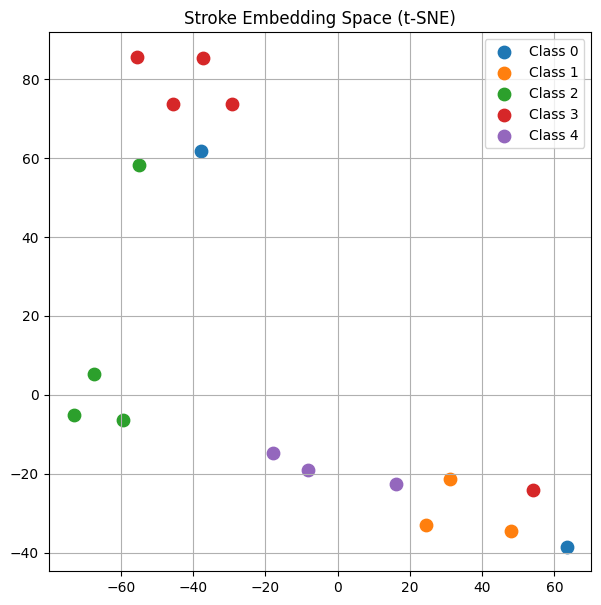

In [18]:
#code to visualize the embeddings clustered

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(7,7))

unique_labels = np.unique(labels)

for lab in unique_labels:

    idx = labels == lab

    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f"Class {lab}",
        s=80
    )

plt.title("Stroke Embedding Space (t-SNE)")
plt.legend()
plt.grid(True)

plt.show()